# Titanic Survival Prediction —  Classification Project

A classification model to predict whether a passenger survived the Titanic disaster.



## Step 1 · Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection  import train_test_split
from sklearn.preprocessing   import LabelEncoder, StandardScaler
from sklearn.linear_model    import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import (
    RandomForestClassifier,
    AdaBoostClassifier
)
from sklearn.metrics import accuracy_score

print(' All libraries imported successfully')

 All libraries imported successfully


## Step 2 · Load Dataset

In [6]:
# Load dataset — update path if needed
df = pd.read_csv('C:/Users/Vijay Pawar/OneDrive/Documents/ALL DATA/COURSES/DATA ANALYTICS & DATA SCIENCE/MACHINE LEARNING/Unsupervised_ML/Project_8/titanic3.csv')

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (1309, 14)


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


In [7]:
# Data Dictionary

# | **Column**    | **Description**                                                      | **Data Type**                             |
# | ------------- | -------------------------------------------------------------------- | ----------------------------------------- |
# | **pclass**    | Passenger class (1 = First, 2 = Second, 3 = Third)                   | Integer                                   |
# | **survived**  | Survival status (1 = Survived, 0 = Did not survive)                  | Integer (Target Variable)                 |
# | **name**      | Full name of the passenger                                           | String                                    |
# | **sex**       | Gender of the passenger (male/female)                                | Categorical                               |
# | **age**       | Age of the passenger in years                                        | Float                                     |
# | **sibsp**     | Number of siblings/spouses aboard the Titanic                        | Integer                                   |
# | **parch**     | Number of parents/children aboard the Titanic                        | Integer                                   |
# | **ticket**    | Passenger's ticket number                                            | String                                    |
# | **fare**      | Ticket fare paid                                                     | Float                                     |
# | **cabin**     | Cabin number assigned to the passenger                               | String (may contain missing values)       |
# | **embarked**  | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) | Categorical                               |
# | **boat**      | Lifeboat number used by survivors                                    | String (mostly missing for non-survivors) |
# | **body**      | Body identification number (if recovered)                            | Float (mostly missing)                    |
# | **home.dest** | Passenger's home city or final destination                           | String                                    |


## Step 3 · Basic Data Understanding

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 210.3 KB


In [9]:
print('Missing values per column:')
df.isnull().sum()

Missing values per column:


pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

## Step 4 · Data Cleaning & Handling Missing Values

In [10]:
# ── Drop data-leakage columns ──────────────────────────────────────────────
# 'boat'  → only survivors were assigned boats (direct leakage)
# 'body'  → only non-survivors had body numbers (direct leakage)
# 'home.dest' → too many nulls (564) and low predictive value
df = df.drop(columns=['body', 'boat', 'home.dest'], errors='ignore')

# ── Numerical: fill with median (robust to outliers) ───────────────────────
df['age']  = df['age'].fillna(df['age'].median())
df['fare'] = df['fare'].fillna(df['fare'].median())

# ── Categorical: fill with most frequent value ─────────────────────────────
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# ── Cabin: extract deck letter instead of dropping entirely ────────────────
# A cabin like 'B5' tells us the deck (B). Unknown → 'U'
df['deck'] = df['cabin'].apply(lambda x: str(x)[0] if pd.notna(x) else 'U')
df = df.drop(columns=['cabin'])

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
pclass      0
survived    0
name        0
sex         0
age         0
sibsp       0
parch       0
ticket      0
fare        0
embarked    0
deck        0
dtype: int64


## Step 5 · Feature Engineering  

| Feature | Why it helps |
|---|---|
| `family_size` | Solo travellers and very large families had lower survival |
| `is_alone` | Binary shortcut for the solo-traveller signal |
| `fare_per_person` | Corrects fare inflation from group bookings |


In [11]:
# 1. Family size
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 2. Is alone?
df['is_alone'] = (df['family_size'] == 1).astype(int)


# 3. Fare per person
df['fare_per_person'] = df['fare'] / df['family_size']

# Drop high-cardinality text columns
df = df.drop(columns=['name', 'ticket'], errors='ignore')

print('Features after engineering:')
print(df.columns.tolist())

Features after engineering:
['pclass', 'survived', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck', 'family_size', 'is_alone', 'fare_per_person']


## Step 6 · Exploratory Data Analysis (EDA)

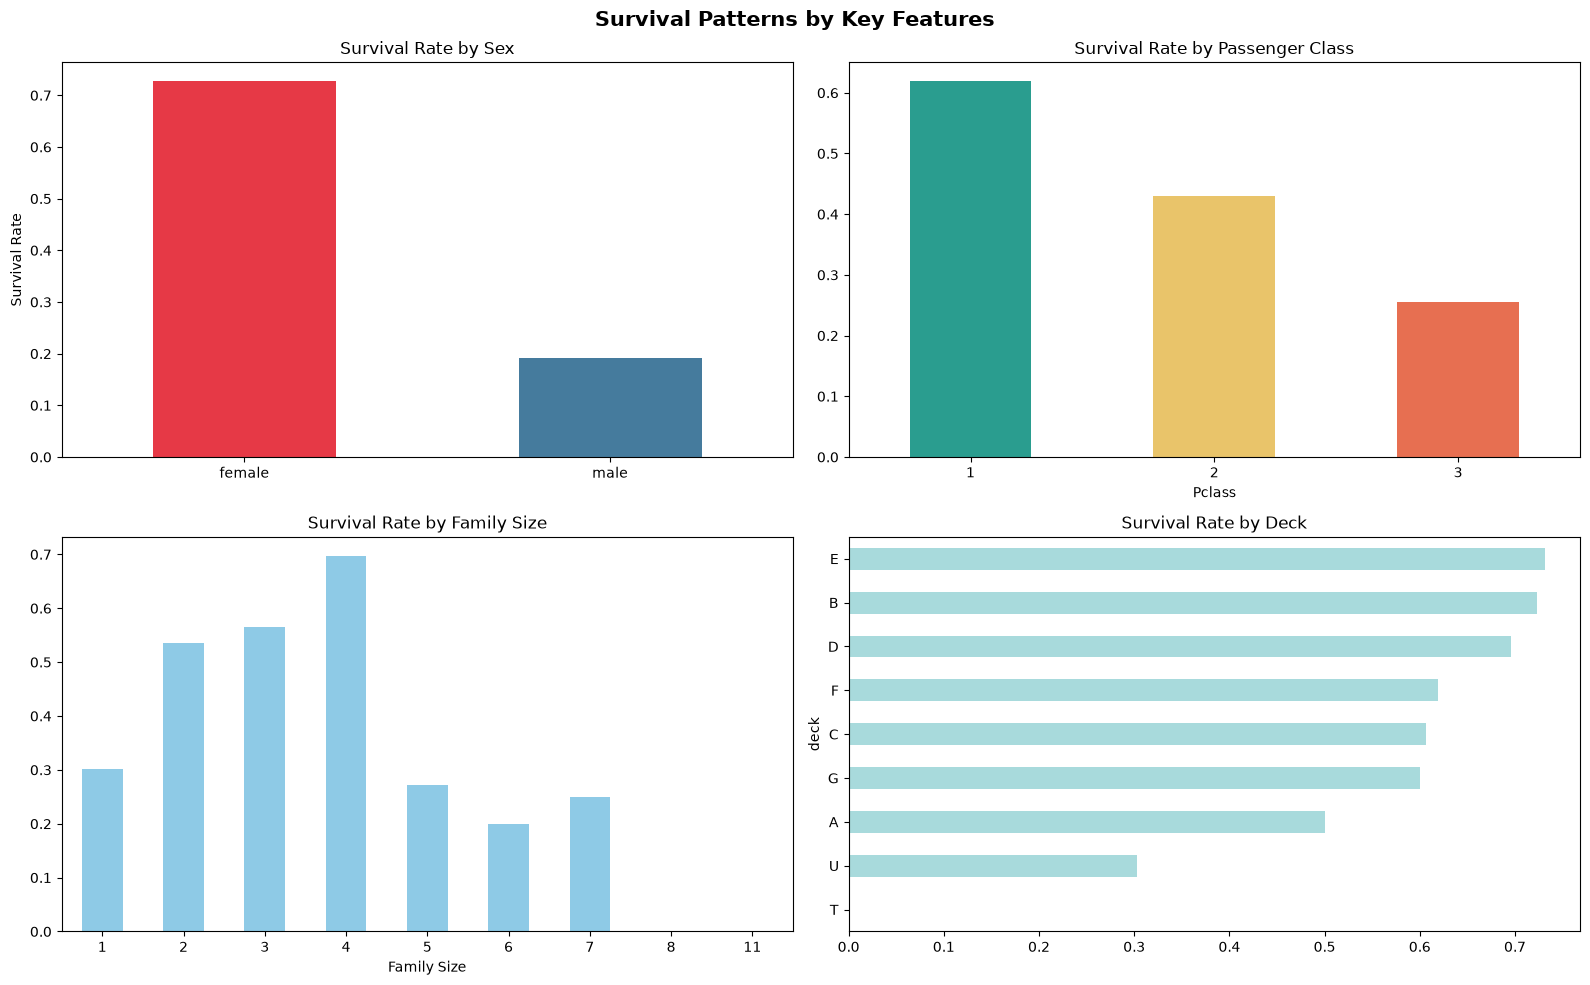

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Survival Patterns by Key Features', fontsize=15, fontweight='bold')

# 1. Survival by Sex
df.groupby('sex')['survived'].mean().plot(kind='bar', ax=axes[0,0],
    color=['#e63946','#457b9d'], rot=0)
axes[0,0].set_title('Survival Rate by Sex')
axes[0,0].set_ylabel('Survival Rate')
axes[0,0].set_xlabel('')

# 2. Survival by Pclass
df.groupby('pclass')['survived'].mean().plot(kind='bar', ax=axes[0,1],
    color=['#2a9d8f','#e9c46a','#e76f51'], rot=0)
axes[0,1].set_title('Survival Rate by Passenger Class')
axes[0,1].set_xlabel('Pclass')



# 3. Survival by Family Size
df.groupby('family_size')['survived'].mean().plot(kind='bar', ax=axes[1,0],
    color='#8ecae6', rot=0)
axes[1,0].set_title('Survival Rate by Family Size')
axes[1,0].set_xlabel('Family Size')

# 4. Survival by Deck
df.groupby('deck')['survived'].mean().sort_values().plot(kind='barh', ax=axes[1,1],
    color='#a8dadc')
axes[1,1].set_title('Survival Rate by Deck')

plt.tight_layout()
plt.show()

## Step 7 · Encode Categorical Features

In [13]:
cat_cols = ['sex', 'deck']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

print('Data types after encoding:')
print(df.dtypes)

Data types after encoding:
pclass               int64
survived             int64
sex                  int64
age                float64
sibsp                int64
parch                int64
fare               float64
embarked               str
deck                 int64
family_size          int64
is_alone             int64
fare_per_person    float64
dtype: object


In [14]:
df.head()

,pclass,survived,sex,age,sibsp,parch,fare,embarked,deck,family_size,is_alone,fare_per_person
0,1,1,0,29.0000,0,0,211.3375,S,1,1,1,211.3375
1,1,1,1,0.9167,1,2,151.5500,S,2,4,0,37.8875
2,1,0,0,2.0000,1,2,151.5500,S,2,4,0,37.8875
3,1,0,1,30.0000,1,2,151.5500,S,2,4,0,37.8875
4,1,0,0,25.0000,1,2,151.5500,S,2,4,0,37.8875


In [15]:

# One-Hot Encode the 'embarked' column
df = pd.get_dummies(df, columns=['embarked'], dtype=int,drop_first=True)

# View the updated DataFrame
print(df.head())

   pclass  survived  sex      age  sibsp  parch      fare  deck  family_size  \
0       1         1    0  29.0000      0      0  211.3375     1            1   
1       1         1    1   0.9167      1      2  151.5500     2            4   
2       1         0    0   2.0000      1      2  151.5500     2            4   
3       1         0    1  30.0000      1      2  151.5500     2            4   
4       1         0    0  25.0000      1      2  151.5500     2            4   

   is_alone  fare_per_person  embarked_Q  embarked_S  
0         1         211.3375           0           1  
1         0          37.8875           0           1  
2         0          37.8875           0           1  
3         0          37.8875           0           1  
4         0          37.8875           0           1  


## Step 8 · Define Features & Target

In [16]:
X = df.drop(columns=['survived'])
y = df['survived']

print(f'Feature matrix shape : {X.shape}')
print(f'Features             : {X.columns.tolist()}')
print(f'\nTarget distribution  :')
print(y.value_counts())
print(f'\nSurvival rate        : {y.mean():.2%}')

Feature matrix shape : (1309, 12)
Features             : ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'deck', 'family_size', 'is_alone', 'fare_per_person', 'embarked_Q', 'embarked_S']

Target distribution  :
survived
0    809
1    500
Name: count, dtype: int64

Survival rate        : 38.20%


## Step 9 · Train / Test Split (Stratified)

In [17]:
# stratify=y ensures both sets have the same survival ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Training set   : {X_train.shape[0]} rows')
print(f'Test set       : {X_test.shape[0]} rows')
print(f'Train survival : {y_train.mean():.2%}')
print(f'Test survival  : {y_test.mean():.2%}')

Training set   : 1047 rows
Test set       : 262 rows
Train survival : 38.20%
Test survival  : 38.17%


## Step 10 · Feature Scaling

In [18]:
scaler = StandardScaler()

# fit on train only — transform both
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)   # no data leakage

## Step 11 · Model Training & Comparison (4 Algorithms)

In [19]:
models = {
    'Logistic Regression' : LogisticRegression(),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, random_state=42),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=200, random_state=42),
}

results = {}

print(f"{'Model':<26} {'Accuracy':>10}")
print('=' * 40)

for name, model in models.items():
    # Train model
    model.fit(X_train_sc, y_train)

    # Predict
    preds = model.predict(X_test_sc)

    # Accuracy
    acc = accuracy_score(y_test, preds)

    # Store results
    results[name] = {
        'accuracy': acc,
        'model': model
    }

    print(f"{name:<26} {acc:10.4f}")

print('=' * 40)

# Best model based on accuracy
best_name = max(results, key=lambda k: results[k]['accuracy'])
print(f"\nBest model by Accuracy: {best_name}")

Model                        Accuracy
Logistic Regression            0.8321
Decision Tree                  0.7672
Random Forest                  0.7748
AdaBoost                       0.8282

Best model by Accuracy: Logistic Regression


In [1]:
import subprocess
import sys

process = subprocess.Popen(
    [sys.executable, "-m", "streamlit", "run", "app.py"]
)

print("Streamlit is running!")
print("Open: http://localhost:8501")

Streamlit is running!
Open: http://localhost:8501
